# Mean Shift Cluster

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# SciPy
from scipy.stats import skew, kurtosis           
from scipy.spatial import ConvexHull, QhullError
from scipy.spatial.distance import cdist        

# scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    adjusted_rand_score as ARI,
)
from sklearn.neighbors import NearestNeighbors

# Analisis Deskriptif

Saham   N  Minimum  Maximum         Mean
 UNTR 234  20100.0  28500.0 24578.739316
 PANI 234   7350.0  19100.0 12981.517094
 ICBP 234   8975.0  12800.0 11080.128205
 TPIA 234   5425.0  10550.0  8276.816239
 AMMN 234   4610.0  10900.0  8157.542735
 INDF 234   6675.0   8525.0  7657.799145
 INKP 234   4350.0   8850.0  6667.628205
 ASII 234   4430.0   5750.0  4909.850427
 CPIN 234   3980.0   5275.0  4711.559829
 INCO 234   1840.0   4400.0  3390.811966
 SMGR 234   2090.0   4570.0  3042.094017
 BRIS 234   2080.0   3160.0  2781.538462
 TLKM 234   2290.0   3420.0  2754.316239
 PTRO 234   1165.0   4180.0  2725.523504
 PTBA 234   2300.0   3140.0  2694.829060
 ADRO 234   1645.0   4040.0  2496.495726
 EXCL 234   2090.0   2960.0  2305.982906
 ISAT 234   1255.0   2825.0  2166.768162
 ANTM 234   1315.0   3550.0  2030.363248
 MDKA 234   1040.0   2730.0  1984.188034
 UNVR 234   1015.0   2440.0  1721.602564
 PGAS 234   1435.0   1885.0  1598.226496
 KLBF 234   1015.0   1750.0  1426.111111
 MAPI 234   1095

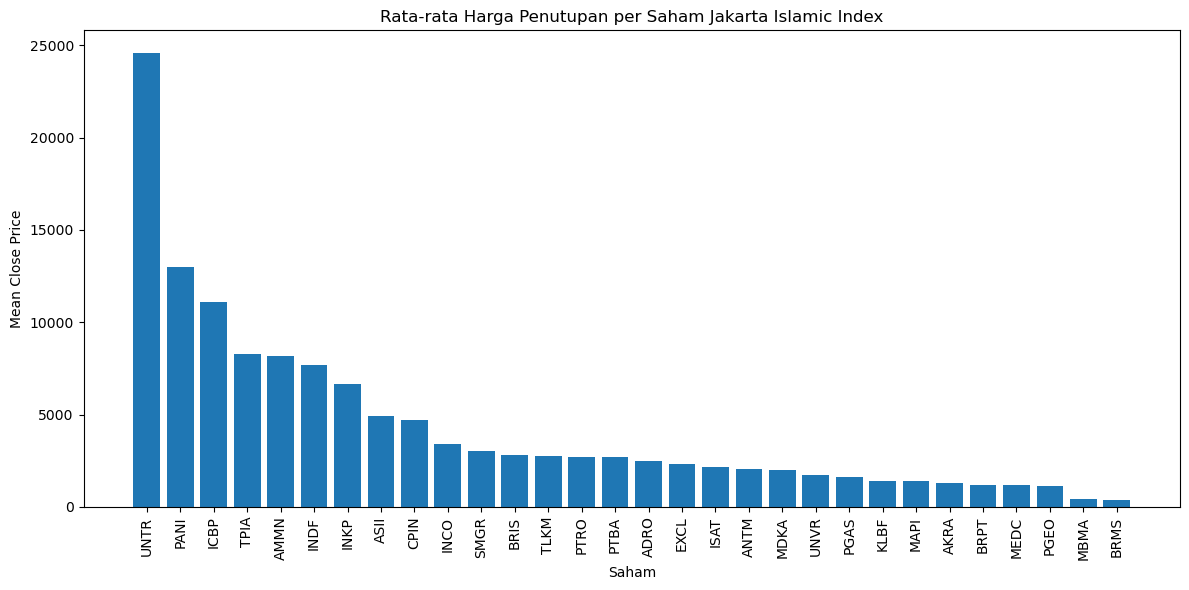

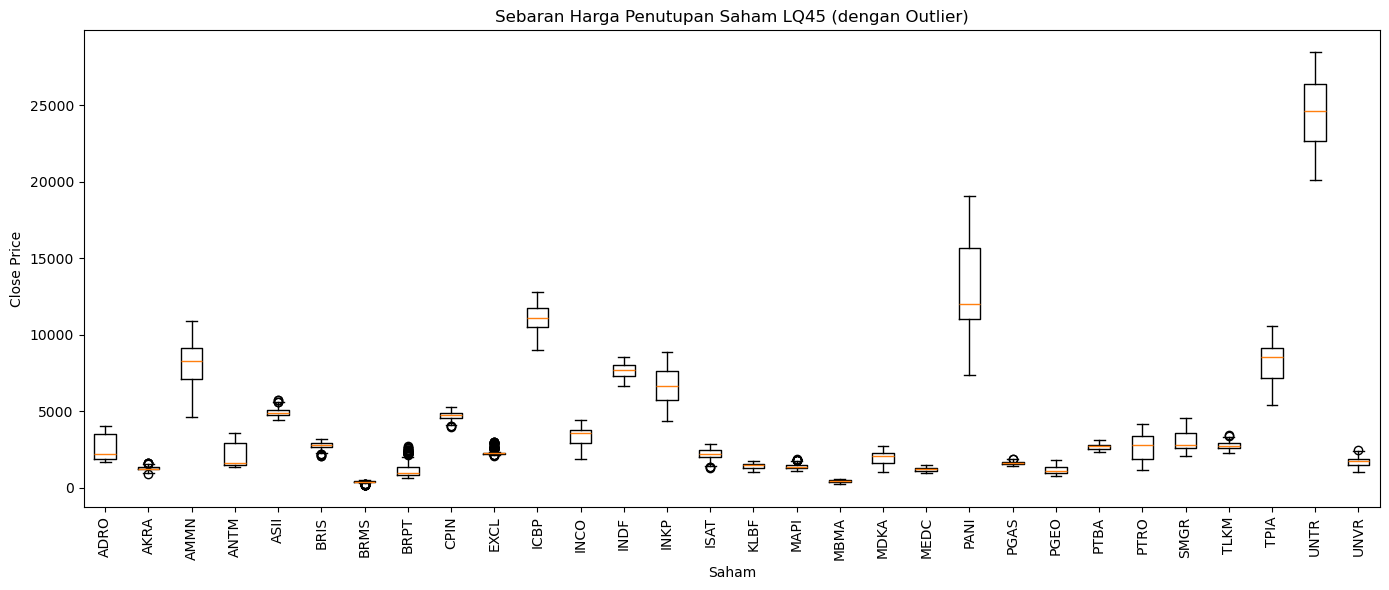

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Path file Excel multi-sheet
excel_path = r"D:\Semester 1-7\SKRIPSI\8. Prosiding\Data\JII_stocks_data.xlsx"

# Baca semua sheet
all_sheets = pd.read_excel(excel_path, sheet_name=None)

rows = []
close_data = {}

for ticker, df in all_sheets.items():
    if "Close" not in df.columns:
        continue
    
    df = df.dropna(subset=["Close"])
    N = len(df)
    Minimum = df["Close"].min()
    Maximum = df["Close"].max()
    Mean = df["Close"].mean()
    
    rows.append({
        "Saham": ticker,
        "N": N,
        "Minimum": Minimum,
        "Maximum": Maximum,
        "Mean": Mean
    })
    
    close_data[ticker] = df["Close"].values  # simpan untuk boxplot

# DataFrame ringkasan
stat_df = pd.DataFrame(rows).sort_values("Mean", ascending=False)

print(stat_df.to_string(index=False))

# === 1) Bar chart rata-rata harga penutupan ===
plt.figure(figsize=(12,6))
plt.bar(stat_df["Saham"], stat_df["Mean"])
plt.title("Rata-rata Harga Penutupan per Saham Jakarta Islamic Index")
plt.xlabel("Saham")
plt.ylabel("Mean Close Price")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# === 2) Boxplot harga penutupan per saham ===
plt.figure(figsize=(14,6))
plt.boxplot(close_data.values(), labels=close_data.keys(), showfliers=True)
plt.title("Sebaran Harga Penutupan Saham LQ45 (dengan Outlier)")
plt.xlabel("Saham")
plt.ylabel("Close Price")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [3]:
TRADING_DAYS = None  # kita pakai N aktual dari data
ANNUALIZE = True
RF_ANNUAL = 0.00     # isi kalau mau pakai risk-free tahunan (mis. BI rate); 0.00 jika diabaikan

rows = []
for ticker, d in all_sheets.items():
    if not ({'Date','Adj Close'} <= set(d.columns) or {'Date','Close'} <= set(d.columns)):
        continue

    p = d.copy()
    p['Date'] = pd.to_datetime(p['Date'], errors='coerce')
    p = p.dropna(subset=['Date']).sort_values('Date')

    price_col = 'Adj Close' if 'Adj Close' in p.columns else 'Close'
    p['Ret'] = np.log(p[price_col] / p[price_col].shift(1))
    p = p.dropna(subset=['Ret'])

    if len(p) < 60:
        continue

    N = len(p)  # <- 234 pada kasusmu
    mu_step = p['Ret'].mean()
    sigma_step = p['Ret'].std(ddof=1)

    if ANNUALIZE:
        mu_ann = mu_step * N
        sigma_ann = sigma_step * np.sqrt(N)
        rf_step = np.log1p(RF_ANNUAL) / N if RF_ANNUAL != 0 else 0.0
        sharpe_ann = ((mu_step - rf_step) / sigma_step) * np.sqrt(N) if sigma_step > 0 else np.nan
        rows.append([ticker, mu_ann, sigma_ann, sharpe_ann])
    else:
        rf_step = 0.0  # atau set sesuai kebutuhan
        sharpe_step = (mu_step - rf_step) / sigma_step if sigma_step > 0 else np.nan
        rows.append([ticker, mu_step, sigma_step, sharpe_step])

colnames = ['Ticker','ExpectedReturn','StdDev','Sharpe']  # akan tahunan jika ANNUALIZE=True
df_rank = pd.DataFrame(rows, columns=colnames).dropna()

In [4]:
import numpy as np
import pandas as pd

ANNUALIZE = True
RF_ANNUAL = 0.00  # isi jika ingin risk-free tahunan

rows = []
diag = {
    "total_sheets": 0,
    "skipped_no_cols": 0,
    "skipped_short_len": 0,
    "skipped_zero_sigma": 0,
    "processed": 0
}

for ticker, d in all_sheets.items():
    diag["total_sheets"] += 1
    
    # 1) Validasi kolom
    if not ({'Date','Adj Close'} <= set(d.columns) or {'Date','Close'} <= set(d.columns)):
        diag["skipped_no_cols"] += 1
        continue

    # 2) Siapkan data & return
    p = d.copy()
    p['Date'] = pd.to_datetime(p['Date'], errors='coerce')
    p = p.dropna(subset=['Date']).sort_values('Date')

    price_col = 'Adj Close' if 'Adj Close' in p.columns else 'Close'
    p['Ret'] = np.log(p[price_col] / p[price_col].shift(1))
    p = p.dropna(subset=['Ret'])

    # 3) Minimal panjang data
    if len(p) < 60:
        diag["skipped_short_len"] += 1
        continue

    # 4) Hitung metrik step (harian)
    N = len(p)             # contoh: 234
    mu_step = p['Ret'].mean()
    sigma_step = p['Ret'].std(ddof=1)

    # Jika sigma==0, Sharpe akan NaN → tandai & lewati
    if not np.isfinite(sigma_step) or sigma_step == 0:
        diag["skipped_zero_sigma"] += 1
        continue

    # 5) Annualize (berdasarkan N aktual)
    if ANNUALIZE:
        mu_ann = mu_step * N
        sigma_ann = sigma_step * np.sqrt(N)
        rf_step = np.log1p(RF_ANNUAL) / N if RF_ANNUAL != 0 else 0.0
        sharpe_ann = ((mu_step - rf_step) / sigma_step) * np.sqrt(N)
        rows.append([ticker, mu_ann, sigma_ann, sharpe_ann, N])
    else:
        rf_step = 0.0  # atau set sesuai kebutuhan
        sharpe_step = (mu_step - rf_step) / sigma_step
        rows.append([ticker, mu_step, sigma_step, sharpe_step, N])

    diag["processed"] += 1

# 6) Buat DataFrame & JANGAN langsung drop semua NaN (biar kelihatan)
colnames = ['Ticker','ExpectedReturn','StdDev','Sharpe','N']
df_rank = pd.DataFrame(rows, columns=colnames)

# 7) Tampilkan ringkasan diagnostik
print("=== DIAGNOSTIK ===")
for k, v in diag.items():
    print(f"{k}: {v}")

print("\n=== DF RANK (5 teratas) ===")
print(df_rank.head().to_string(index=False))

# 8) Jika kosong, beri petunjuk
if df_rank.empty:
    print("\n[INFO] df_rank kosong. Penyebab umum:")
    print("- Kolom 'Date' + ('Adj Close' atau 'Close') tidak lengkap di semua sheet")
    print("- Banyak sheet punya panjang data < 60 baris setelah hitung return")
    print("- Semua sigma_step == 0 (harga hampir konstan) sehingga Sharpe NaN di-skip")

# 9) Kalau ingin ranking & print TOP 3 (hanya jika tidak kosong)
if not df_rank.empty:
    # filter baris valid (finite) saja
    valid = df_rank[np.isfinite(df_rank['ExpectedReturn']) & np.isfinite(df_rank['StdDev']) & np.isfinite(df_rank['Sharpe'])]
    if valid.empty:
        print("\n[INFO] Tidak ada baris dengan metrik finite untuk diranking.")
    else:
        top3_return = valid.sort_values('ExpectedReturn', ascending=False).head(3)
        top3_sharpe = valid.sort_values('Sharpe', ascending=False).head(3)

        print("\n=== TOP 3 RETURN (annualized jika ANNUALIZE=True) ===")
        print(top3_return[['Ticker','ExpectedReturn','StdDev','Sharpe','N']].to_string(index=False))

        print("\n=== TOP 3 SHARPE (annualized jika ANNUALIZE=True) ===")
        print(top3_sharpe[['Ticker','Sharpe','ExpectedReturn','StdDev','N']].to_string(index=False))

=== DIAGNOSTIK ===
total_sheets: 30
skipped_no_cols: 0
skipped_short_len: 0
skipped_zero_sigma: 0
processed: 30

=== DF RANK (5 teratas) ===
Ticker  ExpectedReturn   StdDev    Sharpe   N
  ADRO       -0.596523 0.588624 -1.013420 233
  AKRA       -0.145682 0.457414 -0.318491 233
  AMMN       -0.309730 0.569156 -0.544193 233
  ANTM        0.827551 0.491847  1.682536 233
  ASII        0.141061 0.280756  0.502432 233

=== TOP 3 RETURN (annualized jika ANNUALIZE=True) ===
Ticker  ExpectedReturn   StdDev   Sharpe   N
  BRMS        1.077559 0.724271 1.487784 233
  PTRO        1.050954 0.813084 1.292552 233
  ANTM        0.827551 0.491847 1.682536 233

=== TOP 3 SHARPE (annualized jika ANNUALIZE=True) ===
Ticker   Sharpe  ExpectedReturn   StdDev   N
  ANTM 1.682536        0.827551 0.491847 233
  BRMS 1.487784        1.077559 0.724271 233
  PTRO 1.292552        1.050954 0.813084 233


In [5]:
# --- Statistik Deskriptif Sederhana (N, Mean, StdDev, Min, Max) ---

# Top-3 berdasarkan hasilmu sebelumnya
top3 = ["ANTM", "BRMS", "PTRO"]  # ganti kalau perlu

def daily_log_returns(sheet):
    price_col = 'Adj Close' if 'Adj Close' in sheet.columns else 'Close'
    p = sheet[['Date', price_col]].copy()
    p['Date'] = pd.to_datetime(p['Date'], errors='coerce')
    p = p.dropna().sort_values('Date')
    r = np.log(p[price_col] / p[price_col].shift(1)).dropna()
    return r

rows = []
for t in top3:
    r = daily_log_returns(all_sheets[t])
    rows.append([t, len(r), r.mean(), r.std(ddof=1), r.min(), r.max()])

stat_des_sederhana = pd.DataFrame(
    rows, columns=['Ticker','N','Mean','StdDev','Min','Max']
).set_index('Ticker')

print(stat_des_sederhana.to_string())

# (opsional) versi persen agar mudah dibaca
fmt = stat_des_sederhana.copy()
for c in ['Mean','StdDev','Min','Max']:
    fmt[c] = (fmt[c]*100).map(lambda x: f"{x:.2f}%")
print("\n-- Formatted (%) --")
print(fmt.to_string())

          N      Mean    StdDev       Min       Max
Ticker                                             
ANTM    233  0.003552  0.032222 -0.155168  0.099923
BRMS    233  0.004625  0.047449 -0.156161  0.161119
PTRO    233  0.004511  0.053267 -0.282460  0.221261

-- Formatted (%) --
          N   Mean StdDev      Min     Max
Ticker                                    
ANTM    233  0.36%  3.22%  -15.52%   9.99%
BRMS    233  0.46%  4.74%  -15.62%  16.11%
PTRO    233  0.45%  5.33%  -28.25%  22.13%


# Mean Shift

- Konfigurasi Umum

In [6]:
# === KONSTANTA / CONFIG ===
EXCEL_PATH  = r"D:\Semester 1-7\SKRIPSI\8. Prosiding\Data\3Variabel_JII.xlsx"
REQUIRED_COLS = ["Ticker", "ExpectedReturn", "Variance", "AvgTradingVolume"]
QUANTILE_BW_DEFAULT = 0.20
PLOT_3D     = True
EXPORT_CSV  = True

# === HELPER ===
def banner(title):
    print("\n" + "="*80)
    print(title.upper())
    print("="*80)

def head_tail(df, n=3):
    return pd.concat([df.head(n), df.tail(n)])

- LOAD & VALIDASI DATA

In [7]:
banner("STEP 0 — LOAD & VALIDASI DATA")
df = pd.read_excel(EXCEL_PATH)

# cek kolom wajib
missing = [c for c in REQUIRED_COLS if c not in df.columns]
if missing:
    raise ValueError(f"Kolom hilang: {missing}. Pastikan ada: {REQUIRED_COLS}")

print(f"Jumlah baris awal: {len(df)}")
print("Pratinjau kolom:", list(df.columns))

# pastikan numerik
for c in ["ExpectedReturn","Variance","AvgTradingVolume"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

before = len(df)
df = df.dropna(subset=["ExpectedReturn","Variance","AvgTradingVolume"]).copy()
print(f"Hapus NaN pada fitur utama: {before-len(df)} baris | Sisa: {len(df)}")

print("\nContoh data:")
print(head_tail(df[["Ticker","ExpectedReturn","Variance","AvgTradingVolume"]]).to_string(index=False))


STEP 0 — LOAD & VALIDASI DATA
Jumlah baris awal: 30
Pratinjau kolom: ['Ticker', 'ExpectedReturn', 'Variance', 'AvgTradingVolume']
Hapus NaN pada fitur utama: 0 baris | Sisa: 30

Contoh data:
Ticker  ExpectedReturn  Variance  AvgTradingVolume
  ADRO       -0.002560  0.001487      1.001215e+08
  AKRA       -0.000625  0.000898      2.331143e+07
  AMMN       -0.001329  0.001390      2.845912e+07
  TPIA       -0.000648  0.001882      1.539936e+07
  UNTR       -0.000180  0.000427      3.926456e+06
  UNVR       -0.001054  0.001084      3.731572e+07


- Step 1 — Feature engineering (log volume) + statistik ringkas

In [8]:
banner("STEP 1 — FEATURE ENGINEERING (LOG10 VOLUME) + STATISTIK")
df["LogAvgTradingVolume"] = np.log10(df["AvgTradingVolume"].clip(lower=1.0))

feat_cols = ["ExpectedReturn", "Variance", "LogAvgTradingVolume"]
print("Fitur yang dipakai:", feat_cols)

print("\nStatistik ringkas fitur:")
print(df[feat_cols].describe().T.to_string())

print("\nContoh fitur (head & tail):")
print(head_tail(df[["Ticker"] + feat_cols]).to_string(index=False))


STEP 1 — FEATURE ENGINEERING (LOG10 VOLUME) + STATISTIK
Fitur yang dipakai: ['ExpectedReturn', 'Variance', 'LogAvgTradingVolume']

Statistik ringkas fitur:
                     count      mean       std       min       25%       50%       75%       max
ExpectedReturn        30.0  0.000299  0.001771 -0.002560 -0.000901 -0.000180  0.000805  0.004625
Variance              30.0  0.001064  0.000688  0.000224  0.000486  0.000997  0.001463  0.002837
LogAvgTradingVolume   30.0  7.505829  0.506539  6.594001  7.186880  7.490510  7.800327  8.883332

Contoh fitur (head & tail):
Ticker  ExpectedReturn  Variance  LogAvgTradingVolume
  ADRO       -0.002560  0.001487             8.000527
  AKRA       -0.000625  0.000898             7.367569
  AMMN       -0.001329  0.001390             7.454221
  TPIA       -0.000648  0.001882             7.187503
  UNTR       -0.000180  0.000427             6.594001
  UNVR       -0.001054  0.001084             7.571892


- Step 2 — Scaling (StandardScaler) + cek mean≈0, std≈1

In [9]:
banner("STEP 2 — SCALING (STANDARD SCALER) + CEK SKALA")
X_raw = df[feat_cols].values
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

scaled_df = pd.DataFrame(X, columns=[f"{c}_scaled" for c in feat_cols])
check_stats = pd.DataFrame({
    "mean_scaled": scaled_df.mean().values,
    "std_scaled":  scaled_df.std(ddof=0).values
}, index=scaled_df.columns)

print("Parameter scaler (skala asli):")
print(pd.DataFrame({"mean": scaler.mean_, "scale": scaler.scale_}, index=feat_cols).to_string())

print("\nCek hasil scaling (harus mean≈0, std≈1):")
print(check_stats.to_string())

print("\nPratinjau X_scaled (head & tail):")
print(head_tail(scaled_df).to_string(index=False))


STEP 2 — SCALING (STANDARD SCALER) + CEK SKALA
Parameter scaler (skala asli):
                         mean     scale
ExpectedReturn       0.000299  0.001741
Variance             0.001064  0.000676
LogAvgTradingVolume  7.505829  0.498025

Cek hasil scaling (harus mean≈0, std≈1):
                             mean_scaled  std_scaled
ExpectedReturn_scaled       2.220446e-17         1.0
Variance_scaled             7.494005e-17         1.0
LogAvgTradingVolume_scaled -2.451743e-16         1.0

Pratinjau X_scaled (head & tail):
 ExpectedReturn_scaled  Variance_scaled  LogAvgTradingVolume_scaled
             -1.642213         0.625498                    0.993321
             -0.530959        -0.245349                   -0.277617
             -0.935312         0.482483                   -0.103624
             -0.543987         1.209385                   -0.639178
             -0.275462        -0.941562                   -1.830889
             -0.777321         0.029109                    0.132

- Step 3 — Estimasi bandwidth & seleksi (multi-kriteria)

In [10]:
# === FUNGSI EVALUASI h (VERSI FINAL) ===
def evaluate_h(
    X,
    h: float,
    bin_seeding: bool = True,
    n_boot: int = 8,
    min_cluster_size: int = 2,
    random_state: int = 42,
    jitter_frac_of_h: float = 0.05,   # jitter proporsional ke bandwidth (di ruang terstandardisasi)
):
    """
    Evaluasi bandwidth h untuk MeanShift di ruang fitur yang SUDAH discale:
    - n_clusters, n_singletons
    - silhouette_no_singleton : silhouette rata-rata tanpa cluster berukuran < min_cluster_size
    - silhouette_penalized    : silhouette * penalty(singleton)
    - stability_ARI           : rerata Adjusted Rand Index baseline vs jitter-perturbed clustering
    """
    # 0) Fit baseline di X
    ms0 = MeanShift(bandwidth=h, bin_seeding=bin_seeding)
    labels0 = ms0.fit_predict(X)

    # 1) Ukuran klaster baseline
    vc = pd.Series(labels0).value_counts()
    n_clusters = int(len(vc))
    n_singletons = int((vc == 1).sum())

    # 2) Silhouette tanpa singleton
    keep = vc[vc >= min_cluster_size].index
    mask = np.isin(labels0, keep)
    if mask.sum() >= 3 and len(np.unique(labels0[mask])) >= 2:
        sil = float(silhouette_score(X[mask], labels0[mask], metric="euclidean"))
    else:
        sil = np.nan

    # 3) Penalti singleton
    penalty = 1.0 / (1.0 + n_singletons)   # makin banyak singleton → penalti makin besar
    sil_penalized = float(sil * penalty) if np.isfinite(sil) else np.nan

    # 4) Stabilitas (ARI): jitter kecil + map kembali ke X dengan nearest centers
    rng = np.random.RandomState(random_state)
    aris = []
    if (n_clusters >= 2) and np.isfinite(sil):
        # skala jitter proporsional ke h agar konsisten terhadap skala bandwidth
        jitter = max(1e-6, jitter_frac_of_h * float(h))
        for _ in range(n_boot):
            Xp = X + rng.normal(scale=jitter, size=X.shape)  # jitter di ruang scaled
            msp = MeanShift(bandwidth=h, bin_seeding=bin_seeding).fit(Xp)
            centers_p = msp.cluster_centers_

            # Map label hasil jitter ke TITIK X (bukan Xp) via pusat terdekat
            nn = NearestNeighbors(n_neighbors=1).fit(centers_p)
            lbl_p_on_X = nn.kneighbors(X, return_distance=False).ravel()

            aris.append(ARI(labels0, lbl_p_on_X))

    stability = float(np.mean(aris)) if len(aris) else np.nan

    return {
        "h": float(h),
        "n_clusters": n_clusters,
        "n_singletons": n_singletons,
        "silhouette_no_singleton": sil if np.isfinite(sil) else np.nan,
        "silhouette_penalized": sil_penalized if np.isfinite(sil_penalized) else np.nan,
        "stability_ARI": stability if np.isfinite(stability) else np.nan
    }

# === GRID AWAL BERDASARKAN QUANTILE ===
banner("STEP 3 — ESTIMASI BANDWIDTH & SELEKSI (MULTI-KRITERIA)")
q_grid = [0.10, 0.15, 0.20, 0.25, 0.30]
rows = []

for q in q_grid:
    h_q = estimate_bandwidth(X, quantile=q, n_samples=len(X), random_state=42)
    if not np.isfinite(h_q) or h_q <= 0:
        continue
    met = evaluate_h(X, h_q, bin_seeding=True, n_boot=5)  # bootstrap singkat
    met.update({"quantile": q})
    rows.append(met)

res_q = pd.DataFrame(rows)

print("\nHASIL GRID (quantile → h):")
if res_q.empty:
    print("[WARNING] Tidak ada kandidat bandwidth valid dari grid quantile.")
else:
    print(res_q[["quantile","h","n_clusters","n_singletons",
                 "silhouette_no_singleton","silhouette_penalized","stability_ARI"]]
          .to_string(index=False))

# === PILIH KANDIDAT TERBAIK DARI GRID ===
if not res_q.empty:
    cand = res_q.dropna(subset=["silhouette_penalized"]).copy()
else:
    cand = pd.DataFrame()

if not cand.empty:
    # opsional: target rentang jumlah cluster yang "masuk akal"
    cand["ok_range"] = cand["n_clusters"].between(3, 8)
    cand = cand.sort_values(
        by=["ok_range", "silhouette_penalized", "stability_ARI"],
        ascending=[False, False, False]
    )
    best = cand.iloc[0]
    h_star = float(best["h"])
    q_star = float(best["quantile"])
    print(f"\n[INFO] Kandidat awal: q={q_star} → h={h_star:.6f} | "
          f"k={int(best['n_clusters'])}, singleton={int(best['n_singletons'])}, "
          f"sil*={best['silhouette_penalized']:.4f}, ARI={best['stability_ARI']:.3f}")
else:
    # fallback jika grid tidak menghasilkan kandidat yang memenuhi
    h_star = float(
        estimate_bandwidth(X, quantile=QUANTILE_BW_DEFAULT, n_samples=len(X), random_state=42)
    )
    q_star = float(QUANTILE_BW_DEFAULT)
    print("\n[WARNING] Tidak ada kandidat valid dari grid; memakai h dari QUANTILE_BW_DEFAULT.")

# === LOCAL REFINEMENT DI SEKITAR h* ===
scale = np.array([0.8, 0.9, 1.0, 1.1, 1.2], dtype=float)
# pastikan h_star valid; jika tidak, clamp ke nilai kecil positif agar evaluate_h tetap jalan
h_star = float(h_star) if np.isfinite(h_star) and h_star > 0 else 1e-3
h_local = np.clip(h_star * scale, a_min=1e-6, a_max=None)

rows_ref = []
for h in h_local:
    met = evaluate_h(X, h, bin_seeding=True, n_boot=8)
    met.update({"quantile": np.nan})
    rows_ref.append(met)

res_ref = pd.DataFrame(rows_ref)

print("\nREFINEMENT sekitar h*:")
if res_ref.empty:
    print("[WARNING] Refinement tidak menghasilkan metrik.")
else:
    print(res_ref[["h","n_clusters","n_singletons","silhouette_no_singleton",
                   "silhouette_penalized","stability_ARI"]]
          .to_string(index=False))

# === BANDWIDTH FINAL ===
if res_q.empty and res_ref.empty:
    raise RuntimeError("Gagal memilih bandwidth: tidak ada kandidat dari grid maupun refinement.")

final = pd.concat(
    [res_q.assign(stage="grid"), res_ref.assign(stage="refine")],
    ignore_index=True
).sort_values(by=["silhouette_penalized","stability_ARI"], ascending=[False, False])

best_final = final.iloc[0]
bw = float(best_final["h"])  # <-- dipakai di Step 4

print(f"\n[FINAL] Bandwidth terpilih: h={bw:.6f} | "
      f"k={int(best_final['n_clusters'])}, singleton={int(best_final['n_singletons'])}, "
      f"sil*={best_final['silhouette_penalized']:.4f}, ARI={best_final['stability_ARI']:.3f}")


STEP 3 — ESTIMASI BANDWIDTH & SELEKSI (MULTI-KRITERIA)

HASIL GRID (quantile → h):
 quantile        h  n_clusters  n_singletons  silhouette_no_singleton  silhouette_penalized  stability_ARI
     0.10 0.908748          11             7                 0.418736              0.052342       0.930661
     0.15 1.050478           7             3                 0.320846              0.080211       0.850166
     0.20 1.290984           6             3                 0.333003              0.083251       0.946706
     0.25 1.404596           4             1                 0.338416              0.169208       0.853828
     0.30 1.556230           5             3                 0.438491              0.109623       0.857524

[INFO] Kandidat awal: q=0.25 → h=1.404596 | k=4, singleton=1, sil*=0.1692, ARI=0.854

REFINEMENT sekitar h*:
       h  n_clusters  n_singletons  silhouette_no_singleton  silhouette_penalized  stability_ARI
1.123677           7             3                 0.326405        

In [13]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
import numpy as np
import pandas as pd

def cluster_indices_CH_DB(X, labels, min_cluster_size: int = 2):
    """
    Hitung Calinski–Harabasz (CH) dan Davies–Bouldin (DB).
    - *_all           : pakai semua titik
    - *_no_singleton  : mengecualikan klaster dengan ukuran < min_cluster_size
    """
    labels = np.asarray(labels)
    out = {}

    # --- ALL POINTS ---
    k_all = len(np.unique(labels))
    if k_all >= 2:
        out["CH_all"] = float(calinski_harabasz_score(X, labels))
        out["DB_all"] = float(davies_bouldin_score(X, labels))
    else:
        out["CH_all"] = np.nan
        out["DB_all"] = np.nan

    # --- EXCLUDE SMALL CLUSTERS (e.g., singletons) ---
    vc = pd.Series(labels).value_counts()
    keep = vc[vc >= min_cluster_size].index
    mask = np.isin(labels, keep)
    k_keep = len(np.unique(labels[mask]))

    if mask.sum() >= 2 and k_keep >= 2:
        out["CH_no_singleton"] = float(calinski_harabasz_score(X[mask], labels[mask]))
        out["DB_no_singleton"] = float(davies_bouldin_score(X[mask], labels[mask]))
    else:
        out["CH_no_singleton"] = np.nan
        out["DB_no_singleton"] = np.nan

    out["n_clusters_all"] = k_all
    out["n_clusters_no_singleton"] = k_keep
    out["n_singletons"] = int((vc == 1).sum())
    return out

# ==== CONTOH PEMAKAIAN (jalankan SETELAH Step 4 punya X dan labels) ====
metrics = cluster_indices_CH_DB(X, labels, min_cluster_size=2)
print("\n=== Calinski–Harabasz & Davies–Bouldin ===")
print(f"Clusters (all): {metrics['n_clusters_all']} | Singletons: {metrics['n_singletons']}")
print(f"CH_all = {metrics['CH_all']:.3f}   |   DB_all = {metrics['DB_all']:.3f}")
print(f"Clusters (no_singleton): {metrics['n_clusters_no_singleton']}")
print(f"CH_no_singleton = {metrics['CH_no_singleton']:.3f}   |   DB_no_singleton = {metrics['DB_no_singleton']:.3f}")


=== Calinski–Harabasz & Davies–Bouldin ===
Clusters (all): 3 | Singletons: 0
CH_all = 15.875   |   DB_all = 0.786
Clusters (no_singleton): 3
CH_no_singleton = 15.875   |   DB_no_singleton = 0.786


In [12]:
# STEP 4 — CLUSTERING (MEAN SHIFT)
banner("STEP 4 — CLUSTERING (MEAN SHIFT)")
ms = MeanShift(bandwidth=bw, bin_seeding=True)
labels = ms.fit_predict(X)

centers_scaled = ms.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)  # balik ke skala asli (log10 volume tetap)

df["Cluster"] = labels
n_clusters = df["Cluster"].nunique()
print(f"Jumlah klaster terbentuk (final): {n_clusters}  |  bw={bw:.6f}")

print("\nUkuran masing-masing klaster:")
size_counts = df["Cluster"].value_counts().sort_index()
print(size_counts.to_string())

centers_df = (
    pd.DataFrame(centers, columns=[f"Center_{c}" for c in feat_cols])
      .assign(Cluster=lambda d: d.index)
      .set_index("Cluster")
)
print("\nCentroid (skala asli):")
print(centers_df.to_string())


STEP 4 — CLUSTERING (MEAN SHIFT)
Jumlah klaster terbentuk (final): 3  |  bw=1.685515

Ukuran masing-masing klaster:
Cluster
0    25
1     2
2     3

Centroid (skala asli):
         Center_ExpectedReturn  Center_Variance  Center_LogAvgTradingVolume
Cluster                                                                    
0                    -0.000275         0.000765                    7.312876
1                     0.003708         0.002686                    7.541280
2                     0.004625         0.002251                    8.883332


In [14]:
# STEP 4b — EVALUASI SILHOUETTE (exclude singleton)
banner("STEP 4b — EVALUASI SILHOUETTE (exclude singleton)")
size_counts = df["Cluster"].value_counts().sort_index()
valid_clusters = size_counts[size_counts >= 2].index.tolist()
mask_valid = df["Cluster"].isin(valid_clusters)

if df["Cluster"].nunique() >= 2 and len(valid_clusters) >= 2 and mask_valid.sum() >= 2:
    X_valid = X[mask_valid]
    labels_valid = df.loc[mask_valid, "Cluster"].values

    s_avg = silhouette_score(X_valid, labels_valid, metric="euclidean")
    df.loc[mask_valid, "SilhouetteSample"] = silhouette_samples(X_valid, labels_valid, metric="euclidean")

    per_cluster_sil = (
        df.loc[mask_valid].groupby("Cluster")["SilhouetteSample"]
          .agg(n="count", mean_sil="mean", min_sil="min", max_sil="max")
          .sort_index()
    )
    print(f"PERINGATAN: {len(size_counts) - len(valid_clusters)} klaster singleton dikecualikan.")
    print(f"Silhouette (rata-rata; tanpa singleton): {s_avg:.4f}")
    print("\nRingkasan silhouette per klaster (tanpa singleton):")
    print(per_cluster_sil.to_string())
else:
    print("Silhouette tidak dihitung (klaster valid < 2).")


STEP 4B — EVALUASI SILHOUETTE (EXCLUDE SINGLETON)
PERINGATAN: 0 klaster singleton dikecualikan.
Silhouette (rata-rata; tanpa singleton): 0.4890

Ringkasan silhouette per klaster (tanpa singleton):
          n  mean_sil   min_sil   max_sil
Cluster                                  
0        25  0.521220  0.182307  0.667380
1         2  0.303439  0.217379  0.389498
2         3  0.344446  0.206137  0.424581


In [15]:
# STEP 4c — RELABEL OPSIONAL (urutkan klaster dari risiko terendah → tertinggi)
banner("STEP 4c — RELABEL (berdasarkan Center_Variance naik)")
order = centers_df["Center_Variance"].sort_values().index.tolist()
mapping = {old:new for new,old in enumerate(order)}  # 0=var terendah (low risk), dst.
df["ClusterRelabeled"] = df["Cluster"].map(mapping)

centers_df_relab = centers_df.copy()
centers_df_relab["ClusterRelabeled"] = centers_df_relab.index.map(mapping)
centers_df_relab = centers_df_relab.set_index("ClusterRelabeled").sort_index()

print("Mapping label asli → relabeled:", mapping)
print("\nCentroid (relabeled):")
print(centers_df_relab.to_string())


STEP 4C — RELABEL (BERDASARKAN CENTER_VARIANCE NAIK)
Mapping label asli → relabeled: {0: 0, 2: 1, 1: 2}

Centroid (relabeled):
                  Center_ExpectedReturn  Center_Variance  Center_LogAvgTradingVolume
ClusterRelabeled                                                                    
0                             -0.000275         0.000765                    7.312876
1                              0.004625         0.002251                    8.883332
2                              0.003708         0.002686                    7.541280


In [16]:
import numpy as np
import pandas as pd
from sklearn.metrics import pairwise_distances

# Siapkan tabel fitur scaled + identitas
feat_scaled = pd.DataFrame(X, columns=feat_cols).copy()
feat_scaled["Ticker"]  = df["Ticker"].values
feat_scaled["Cluster"] = df["Cluster"].values

# =============== NEAREST-TO-CENTROID ===============
def pick_nearest_to_centroid(feat_df, centers, feat_cols):
    rows = []
    for c in sorted(feat_df["Cluster"].unique()):
        sub = feat_df[feat_df["Cluster"] == c].copy()
        V = sub[feat_cols].values
        ctr = centers[c]  # center klaster c (scaled)
        dist = np.linalg.norm(V - ctr, axis=1)
        idx = int(np.argmin(dist))
        rows.append({
            "Cluster": int(c),
            "Ticker": sub.iloc[idx]["Ticker"],
            "Method": "nearest_to_centroid",
            "Score": float(dist[idx])  # lebih kecil = lebih baik
        })
    return pd.DataFrame(rows).sort_values("Cluster").reset_index(drop=True)

# =============== MEDOID (paling "tengah" di klaster) ===============
def pick_medoid(feat_df, feat_cols):
    rows = []
    for c in sorted(feat_df["Cluster"].unique()):
        sub = feat_df[feat_df["Cluster"] == c].copy()
        V = sub[feat_cols].values
        if len(sub) == 1:
            rows.append({
                "Cluster": int(c),
                "Ticker": sub.iloc[0]["Ticker"],
                "Method": "medoid",
                "Score": 0.0
            })
            continue
        D = pairwise_distances(V, metric="euclidean")   # jarak antar anggota dalam klaster
        tot = D.sum(axis=1)                             # total jarak ke semua anggota
        idx = int(np.argmin(tot))                       # total jarak minimum = medoid
        rows.append({
            "Cluster": int(c),
            "Ticker": sub.iloc[idx]["Ticker"],
            "Method": "medoid",
            "Score": float(tot[idx] / (len(sub) - 1))   # rata-rata jarak (opsional)
        })
    return pd.DataFrame(rows).sort_values("Cluster").reset_index(drop=True)

# ====== JALANKAN KEDUANYA ======
rep_centroid = pick_nearest_to_centroid(feat_scaled, centers_scaled, feat_cols)
rep_medoid   = pick_medoid(feat_scaled, feat_cols)

print("\n=== NEAREST-TO-CENTROID (1 per cluster) ===")
print(rep_centroid.to_string(index=False))

print("\n=== MEDOID (1 per cluster) ===")
print(rep_medoid.to_string(index=False))

# (Opsional) pilih final berdasarkan preferensi:
# prioritas: medoid > nearest-to-centroid
priority = {"medoid": 0, "nearest_to_centroid": 1}
final_pick = (
    pd.concat([rep_medoid, rep_centroid], ignore_index=True)
      .assign(prio=lambda d: d["Method"].map(priority))
      .sort_values(["Cluster","prio","Score"])
      .groupby("Cluster", as_index=False).first()
      .drop(columns=["prio"])
      .sort_values("Cluster")
      .reset_index(drop=True)
)

print("\n=== FINAL PICK (1 per cluster; medoid diutamakan) ===")
print(final_pick.to_string(index=False))


=== NEAREST-TO-CENTROID (1 per cluster) ===
 Cluster Ticker              Method    Score
       0   AKRA nearest_to_centroid 0.301891
       1   PANI nearest_to_centroid 0.926280
       2   BRMS nearest_to_centroid 0.000000

=== MEDOID (1 per cluster) ===
 Cluster Ticker Method    Score
       0   AKRA medoid 1.137760
       1   PANI medoid 1.852560
       2   BRPT medoid 1.434701

=== FINAL PICK (1 per cluster; medoid diutamakan) ===
 Cluster Ticker Method    Score
       0   AKRA medoid 1.137760
       1   PANI medoid 1.852560
       2   BRPT medoid 1.434701


In [17]:
# STEP 5 — RINGKASAN & DAFTAR ANGGOTA PER KLASTER (untuk MVO per klaster)
banner("STEP 5 — RINGKASAN & ANGGOTA PER KLASTER")
summary = (
    df.groupby("Cluster")
      .agg(Count=("Ticker","count"),
           ExpectedReturn_mean=("ExpectedReturn","mean"),
           Variance_mean=("Variance","mean"),
           LogAvgTradingVolume_mean=("LogAvgTradingVolume","mean"))
      .sort_index()
)
print("Ringkasan per klaster:")
print(summary.to_string())

print("\nDaftar anggota per klaster (label asli):")
members = df[["Cluster","Ticker","ExpectedReturn","Variance","LogAvgTradingVolume"]]\
            .sort_values(["Cluster","Ticker"])
print(members.to_string(index=False))

# (opsional) daftar anggota per klaster relabeled, untuk konsistensi pelabelan risiko
print("\nDaftar anggota per klaster (relabeled):")
members_relab = df[["ClusterRelabeled","Ticker","ExpectedReturn","Variance","LogAvgTradingVolume"]]\
                   .sort_values(["ClusterRelabeled","Ticker"])
print(members_relab.to_string(index=False))

# siapkan struktur untuk tahap MVO berikutnya:
clusters_members = {
    int(c): members.loc[members["Cluster"]==c, "Ticker"].tolist()
    for c in sorted(df["Cluster"].unique())
}
valid_clusters = [int(c) for c, cnt in size_counts.items() if cnt >= 2]  # abaikan singleton seperti di artikel
print("\nCluster → list ticker (untuk MVO):")
for c in sorted(clusters_members):
    flag = "" if c in valid_clusters else "  [abaikan: singleton]"
    print(f"Cluster {c}: {clusters_members[c]}{flag}")


STEP 5 — RINGKASAN & ANGGOTA PER KLASTER
Ringkasan per klaster:
         Count  ExpectedReturn_mean  Variance_mean  LogAvgTradingVolume_mean
Cluster                                                                     
0           25            -0.000380       0.000871                  7.397934
1            2             0.003708       0.002686                  7.541280
2            3             0.003685       0.001593                  8.381316

Daftar anggota per klaster (label asli):
 Cluster Ticker  ExpectedReturn  Variance  LogAvgTradingVolume
       0   ADRO       -0.002560  0.001487             8.000527
       0   AKRA       -0.000625  0.000898             7.367569
       0   AMMN       -0.001329  0.001390             7.454221
       0   ASII        0.000605  0.000338             7.642471
       0   BRIS        0.000195  0.000744             7.526798
       0   CPIN       -0.000451  0.000505             6.781692
       0   EXCL        0.000994  0.000224             7.299947
    


STEP 6 — VISUALISASI 3D (SCALED)


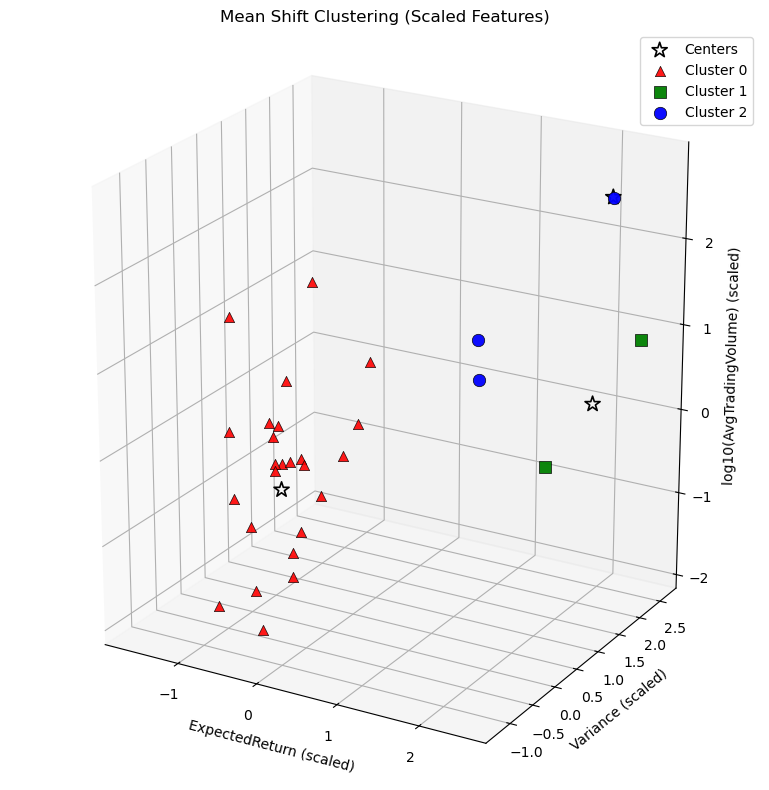

In [20]:
# ==== STEP 6 — VISUALISASI 3D (scaled) ====
if PLOT_3D:
    banner("STEP 6 — VISUALISASI 3D (scaled)")
    import matplotlib.pyplot as plt
    from scipy.spatial import ConvexHull, QhullError
    import numpy as np

    # Pastikan urutan kolom X = [ExpectedReturn, Variance, LogAvgTradingVolume]
    assert X.shape[1] == 3, "X harus 3D: [ExpRet, Var, LogVol]"

    colors  = ['red','green','blue','purple','cyan','orange','magenta','brown']
    markers = ['^','s','o','D','x','P','*','v']
    sizes   = {0: 55, 1: 70, 2: 80}   # klaster kecil dibesarkan sedikit
    alphas  = {0: 0.90, 1: 0.95, 2: 0.95}

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_title("Mean Shift Clustering (Scaled Features)")

    # --- Gambar centers dulu: hollow agar tidak menutup titik ---
    ax.scatter(
        centers_scaled[:,0], centers_scaled[:,1], centers_scaled[:,2],
        marker='*', s=130, facecolors='none', edgecolors='k',
        linewidths=1.2, label="Centers", depthshade=False, zorder=0
    )

    unique_labels = sorted(np.unique(labels))
    SHOW_HULL = False  # True jika ingin garis convex hull

    for idx, cl in enumerate(unique_labels):
        pts = X[labels == cl].copy()

        # --- Jika ada titik tepat di pusat klaster, geser tipis (visual-only) agar terlihat ---
        c = centers_scaled[cl]
        d = np.linalg.norm(pts - c, axis=1)
        coincide = np.where(d < 1e-10)[0]
        if coincide.size > 0:
            eps = 0.012
            for j, k in enumerate(coincide, start=1):
                pts[k] = pts[k] + np.array([eps*j, -eps*j, 0])

        ax.scatter(
            pts[:,0], pts[:,1], pts[:,2],
            c=colors[idx % len(colors)],
            marker=markers[idx % len(markers)],
            s=sizes.get(cl, 60), alpha=alphas.get(cl, 0.9),
            edgecolor='k', linewidths=0.5, label=f"Cluster {cl}",
            depthshade=False, zorder=3
        )

        # (Opsional) convex hull—sering bikin penuh untuk klaster besar
        if SHOW_HULL and pts.shape[0] >= 4:
            try:
                hull = ConvexHull(pts)
                for simplex in hull.simplices:
                    ax.plot(pts[simplex,0], pts[simplex,1], pts[simplex,2],
                            color=colors[idx % len(colors)], alpha=0.25, linewidth=0.8, zorder=1)
            except QhullError:
                pass

        # (Opsional) anotasi khusus klaster 2
        # if cl == 2:
        #     idx2 = np.where(labels == 2)[0]
        #     for i in idx2:
        #         x, y, z = X[i]
        #         ax.text(x, y, z, str(df.iloc[i]["Ticker"]), fontsize=8, zorder=4)

    # Sudut pandang & proporsi sumbu supaya klaster kebaca jelas
    ax.view_init(elev=22, azim=-60)  # coba elev=25, azim=-70 jika mau
    rng = np.ptp(X, axis=0)          # rentang per sumbu
    ax.set_box_aspect((rng[0], rng[1], rng[2]))

    ax.set_xlabel("ExpectedReturn (scaled)")
    ax.set_ylabel("Variance (scaled)")
    ax.set_zlabel("log10(AvgTradingVolume) (scaled)")
    ax.legend()
    plt.tight_layout()
    plt.show()


STEP 6 — VISUALISASI 3D (SCALED)


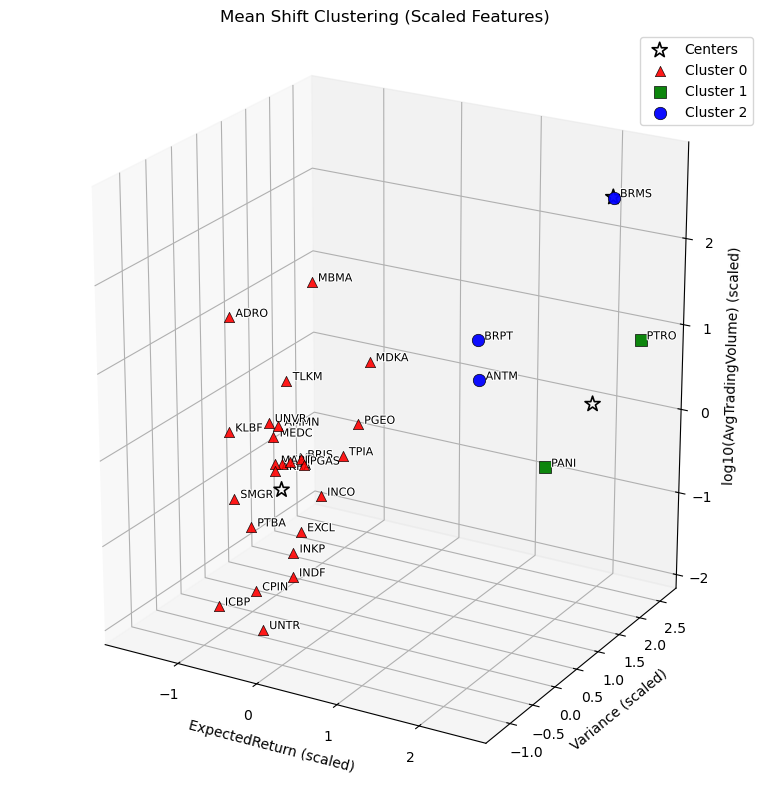

In [21]:
# ==== STEP 6 — VISUALISASI 3D (scaled) ====
if PLOT_3D:
    banner("STEP 6 — VISUALISASI 3D (scaled)")
    import matplotlib.pyplot as plt
    from scipy.spatial import ConvexHull, QhullError
    from matplotlib import patheffects as pe
    import numpy as np

    # Pastikan urutan kolom X = [ExpectedReturn, Variance, LogAvgTradingVolume]
    assert X.shape[1] == 3, "X harus 3D: [ExpRet, Var, LogVol]"

    colors  = ['red','green','blue','purple','cyan','orange','magenta','brown']
    markers = ['^','s','o','D','x','P','*','v']
    sizes   = {0: 55, 1: 70, 2: 80}   # klaster kecil dibesarkan sedikit
    alphas  = {0: 0.90, 1: 0.95, 2: 0.95}

    # ==== (BARU) Opsi label ====
    SHOW_LABELS      = True       # tampilkan label ticker di setiap titik
    LABEL_FONT_SIZE  = 8
    LABEL_OUTLINE_PX = 1.5        # outline putih agar teks terbaca

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_title("Mean Shift Clustering (Scaled Features)")

    # --- Gambar centers dulu: hollow agar tidak menutup titik ---
    ax.scatter(
        centers_scaled[:,0], centers_scaled[:,1], centers_scaled[:,2],
        marker='*', s=130, facecolors='none', edgecolors='k',
        linewidths=1.2, label="Centers", depthshade=False, zorder=0
    )

    unique_labels = sorted(np.unique(labels))
    SHOW_HULL = False  # True jika ingin garis convex hull

    # (BARU) hitung rentang sumbu untuk offset label proporsional skala data
    rng = np.ptp(X, axis=0)
    # offset kecil supaya label tidak tepat menimpa marker
    label_offset = np.array([0.012, 0.012, 0.000]) * (rng + 1e-9)

    for idx, cl in enumerate(unique_labels):
        # (UBAH) simpan indeks aslinya agar label sesuai titik
        idxs = np.where(labels == cl)[0]
        pts = X[idxs].copy()

        # --- Jika ada titik tepat di pusat klaster, geser tipis (visual-only) agar terlihat ---
        c = centers_scaled[cl]
        d = np.linalg.norm(pts - c, axis=1)
        coincide = np.where(d < 1e-10)[0]
        if coincide.size > 0:
            eps = 0.012
            for j, k in enumerate(coincide, start=1):
                pts[k] = pts[k] + np.array([eps*j, -eps*j, 0])

        # Scatter titik per klaster
        ax.scatter(
            pts[:,0], pts[:,1], pts[:,2],
            c=colors[idx % len(colors)],
            marker=markers[idx % len(markers)],
            s=sizes.get(cl, 60), alpha=alphas.get(cl, 0.9),
            edgecolor='k', linewidths=0.5, label=f"Cluster {cl}",
            depthshade=False, zorder=3
        )

        # ==== (BARU) Tampilkan label ticker di setiap titik ====
        if SHOW_LABELS:
            for j, irow in enumerate(idxs):
                tx, ty, tz = pts[j] + label_offset  # posisinya = titik + offset kecil
                text_obj = ax.text(
                    tx, ty, tz,
                    str(df.iloc[irow]["Ticker"]),
                    fontsize=LABEL_FONT_SIZE,
                    zorder=4
                )
                # outline putih supaya kontras (penting di plot 3D berwarna)
                text_obj.set_path_effects([
                    pe.Stroke(linewidth=LABEL_OUTLINE_PX, foreground="white"),
                    pe.Normal()
                ])

        # (Opsional) convex hull—sering bikin penuh untuk klaster besar
        if SHOW_HULL and pts.shape[0] >= 4:
            try:
                hull = ConvexHull(pts)
                for simplex in hull.simplices:
                    ax.plot(pts[simplex,0], pts[simplex,1], pts[simplex,2],
                            color=colors[idx % len(colors)], alpha=0.25, linewidth=0.8, zorder=1)
            except QhullError:
                pass

    # Sudut pandang & proporsi sumbu supaya klaster kebaca jelas
    ax.view_init(elev=22, azim=-60)  # coba elev=25, azim=-70 jika mau
    ax.set_box_aspect((rng[0], rng[1], rng[2]))

    ax.set_xlabel("ExpectedReturn (scaled)")
    ax.set_ylabel("Variance (scaled)")
    ax.set_zlabel("log10(AvgTradingVolume) (scaled)")
    ax.legend()
    plt.tight_layout()
    plt.show()


# Value at Risk

In [29]:
import numpy as np
import pandas as pd
from pathlib import Path

# ========= PARAMETER =========
excel_path = r"D:\Semester 1-7\SKRIPSI\8. Prosiding\Data\JII_stocks_data.xlsx"
tickers    = ["AKRA", "PANI", "BRPT"]
alpha      = 0.95   # 95% confidence → pakai kuantil 5%

# (opsional) isi nilai investasi untuk output rupiah; kalau tidak perlu set ke None
W0 = 100_000_000 

# ========= FUNGSI UTILITAS =========
def _coerce_numeric(s):
    """Paksakan kolom numerik (handle format lokal seperti 1.234,56)."""
    if pd.api.types.is_numeric_dtype(s):
        return s
    s = s.astype(str).str.replace(r"\.", "", regex=True).str.replace(",", ".", regex=False)
    return pd.to_numeric(s, errors="coerce")

def hs_var_1day(returns: pd.Series, alpha: float = 0.95) -> float:
    """Historical Simulation VaR 1-day (dalam satuan return, negatif = loss)."""
    r = pd.Series(returns).dropna()
    if len(r) < 30:
        return np.nan
    q = 1 - alpha  # 0.05 untuk 95%
    return float(r.quantile(q))  # persentil ke-5%

# ========= BACA EXCEL & BENTUK RETURNS =========
xls = pd.ExcelFile(excel_path)

results = []
for t in tickers:
    if t not in xls.sheet_names:
        print(f"[WARNING] Sheet '{t}' tidak ditemukan di file Excel.")
        continue

    df = pd.read_excel(excel_path, sheet_name=t)

    # Normalisasi kolom
    # Pastikan 'Date' bertipe datetime dan harga numerik
    if "Date" not in df.columns:
        raise ValueError(f"Sheet {t}: kolom 'Date' tidak ada.")
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    price_col = "Adj Close" if "Adj Close" in df.columns else ("Close" if "Close" in df.columns else None)
    if price_col is None:
        raise ValueError(f"Sheet {t}: kolom harga 'Adj Close'/'Close' tidak ada.")

    df[price_col] = _coerce_numeric(df[price_col])
    df = df.dropna(subset=["Date", price_col]).sort_values("Date")

    # Hitung return harian (log return lebih stabil)
    ret = np.log(df[price_col] / df[price_col].shift(1))
    var_1d = hs_var_1day(ret, alpha=alpha)

    row = {
        "Ticker": t,
        "VaR_95%_1D_Return": var_1d
    }

    if W0 is not None and np.isfinite(var_1d):
        row["VaR_95%_1D_Rupiah"] = abs(W0 * var_1d)

    results.append(row)

var_df = pd.DataFrame(results)

# ========= FORMAT OUTPUT =========
if not var_df.empty:
    var_df["VaR_95%_1D_Return"] = var_df["VaR_95%_1D_Return"].map(
        lambda x: f"{x:.4%}" if pd.notna(x) else "NA"
    )
    if "VaR_95%_1D_Rupiah" in var_df.columns:
        var_df["VaR_95%_1D_Rupiah"] = var_df["VaR_95%_1D_Rupiah"].map(
            lambda x: f"Rp {x:,.0f}" if pd.notna(x) else "NA"
        )

print("\n=== HASIL VaR 1-Hari (95%) — Historical Simulation ===")
print(var_df.to_string(index=False))


=== HASIL VaR 1-Hari (95%) — Historical Simulation ===
Ticker VaR_95%_1D_Return VaR_95%_1D_Rupiah
  AKRA          -4.4072%      Rp 4,407,223
  PANI          -6.7021%      Rp 6,702,138
  BRPT          -4.5998%      Rp 4,599,808
